# GLM-5.2 cost estimate and cost/accuracy frontier

This notebook reconstructs GLM-5.2 generation cost from all 150 recorded SWE-bench Verified trajectories, compares it with the recorded Kimi-K3 and Claude Opus 5 costs, and plots all three models.

Pricing assumption (checked 2026-08-05): [FriendliAI Model APIs pricing](https://friendli.ai/pricing) lists GLM-5.2 at **$1.40/M uncached input tokens**, **$0.26/M cached input tokens**, and **$4.40/M output tokens**. This is an estimate at those published rates, not a historical invoice.

Token accounting: `total_prompt_tokens` includes cached input. Therefore uncached input is prompt minus cached. Reported reasoning tokens are a subset of completion tokens, not an additional billable category; they are shown separately but charged once at the output rate.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter

REPO = Path.cwd()
if not (REPO / 'results').exists():
    REPO = REPO.parent
DATA = REPO / 'results/swe-bench-verified/2026-07-regraded/results'
assert DATA.exists(), f'Recorded results not found: {DATA}'

MODELS = {
    'GLM-5.2 xhigh': {
        'directory': 'glm-5.2', 'summary': 'glm-5.2/xhigh_n150/official_summary.json',
        'color': '#4c78a8', 'cost_source': 'estimated',
    },
    'Kimi-K3 max': {
        'directory': 'kimi-k3', 'summary': 'kimi-k3/max_n150/official_summary.json',
        'color': '#eb6834', 'cost_source': 'recorded',
    },
    'Claude Opus 5 max': {
        'directory': 'claude-opus-5', 'summary': 'claude-opus-5/max_n150/official_summary.json',
        'color': '#1baf7a', 'cost_source': 'recorded',
    },
}
GLM_RATES_PER_MILLION = {'uncached_input': 1.40, 'cached_input': 0.26, 'output': 4.40}

## Load and validate all trajectories

The aggregation uses `final_metrics`, which is the trajectory-level rollup of per-call usage. Missing reasoning or cost fields remain explicit through coverage counts.

In [2]:
def aggregate_trajectories(model_dir):
    paths = sorted((DATA / model_dir).rglob('trajectory.json'))
    rows = []
    for path in paths:
        metrics = json.loads(path.read_text())['final_metrics']
        extra = metrics.get('extra') or {}
        rows.append({
            'prompt_tokens': metrics.get('total_prompt_tokens', 0) or 0,
            'cached_tokens': metrics.get('total_cached_tokens', 0) or 0,
            'completion_tokens': metrics.get('total_completion_tokens', 0) or 0,
            'reasoning_tokens': extra.get('total_reasoning_tokens', 0) or 0,
            'recorded_cost_usd': metrics.get('total_cost_usd'),
            'steps': metrics.get('total_steps', 0) or 0,
        })
    frame = pd.DataFrame(rows)
    assert len(frame) == 150, f'{model_dir}: expected 150 trajectories, found {len(frame)}'
    assert (frame.cached_tokens <= frame.prompt_tokens).all()
    assert (frame.reasoning_tokens <= frame.completion_tokens).all()
    return {
        'trajectories': len(frame),
        'prompt_tokens': int(frame.prompt_tokens.sum()),
        'cached_tokens': int(frame.cached_tokens.sum()),
        'uncached_tokens': int((frame.prompt_tokens - frame.cached_tokens).sum()),
        'completion_tokens': int(frame.completion_tokens.sum()),
        'reasoning_tokens': int(frame.reasoning_tokens.sum()),
        'visible_output_tokens': int((frame.completion_tokens - frame.reasoning_tokens).sum()),
        'recorded_cost_usd': float(frame.recorded_cost_usd.fillna(0).sum()),
        'cost_records': int(frame.recorded_cost_usd.notna().sum()),
        'steps': int(frame.steps.sum()),
    }

usage = pd.DataFrame({label: aggregate_trajectories(cfg['directory']) for label, cfg in MODELS.items()}).T
usage

,trajectories,prompt_tokens,cached_tokens,uncached_tokens,completion_tokens,reasoning_tokens,visible_output_tokens,recorded_cost_usd,cost_records,steps
GLM-5.2 xhigh,150.0,369319711.0,363484288.0,5835423.0,3859613.0,2636257.0,1223356.0,0.394124,4.0,10516.0
Kimi-K3 max,150.0,217191582.0,209772544.0,7419038.0,3154390.0,1822504.0,1331886.0,132.504727,150.0,7648.0
Claude Opus 5 max,150.0,333074903.0,323246382.0,9828521.0,4474988.0,0.0,4474988.0,334.907840,150.0,7623.0


## Estimate GLM-5.2 and assemble the comparison

Only 4 of 150 GLM trajectories contain a recorded cost, so their partial sum is retained for audit but is not used as the benchmark total. Kimi and Opus use the complete recorded totals.

In [3]:
glm = usage.loc['GLM-5.2 xhigh']
glm_cost_components = pd.Series({
    'uncached input': glm.uncached_tokens / 1_000_000 * GLM_RATES_PER_MILLION['uncached_input'],
    'cached input': glm.cached_tokens / 1_000_000 * GLM_RATES_PER_MILLION['cached_input'],
    'output (includes reasoning)': glm.completion_tokens / 1_000_000 * GLM_RATES_PER_MILLION['output'],
}, name='cost_usd')
glm_estimated_cost = float(glm_cost_components.sum())
display(glm_cost_components.to_frame().style.format('${:,.2f}'))
print(f'Estimated GLM-5.2 total: ${glm_estimated_cost:,.2f}')
print(f'Estimated GLM-5.2 mean/task: ${glm_estimated_cost / 150:,.3f}')

,cost_usd
uncached input,$8.17
cached input,$94.51
output (includes reasoning),$16.98


Estimated GLM-5.2 total: $119.66
Estimated GLM-5.2 mean/task: $0.798


In [4]:
comparison_rows = []
for label, cfg in MODELS.items():
    summary = json.loads((DATA / cfg['summary']).read_text())
    total = summary['total_instances']
    resolved = summary['resolved_instances']
    cost = glm_estimated_cost if cfg['cost_source'] == 'estimated' else usage.loc[label, 'recorded_cost_usd']
    comparison_rows.append({
        'model': label, 'resolved': resolved, 'tasks': total,
        'solve_rate_pct': 100 * resolved / total, 'total_cost_usd': cost,
        'cost_per_task_usd': cost / total, 'cost_per_resolved_usd': cost / resolved,
        'cost_source': cfg['cost_source'], 'color': cfg['color'],
    })
comparison = pd.DataFrame(comparison_rows).set_index('model')
display(comparison.drop(columns='color').style.format({
    'solve_rate_pct': '{:.1f}%', 'total_cost_usd': '${:,.2f}',
    'cost_per_task_usd': '${:.3f}', 'cost_per_resolved_usd': '${:.2f}',
}))

,resolved,tasks,solve_rate_pct,total_cost_usd,cost_per_task_usd,cost_per_resolved_usd,cost_source
model,,,,,,,
GLM-5.2 xhigh,123,150,82.0%,$119.66,$0.798,$0.97,estimated
Kimi-K3 max,145,150,96.7%,$132.50,$0.883,$0.91,recorded
Claude Opus 5 max,149,150,99.3%,$334.91,$2.233,$2.25,recorded


## Cost (log scale) vs. solve rate

The x-axis is mean generation cost per task attempted. The log scale reflects multiplicative cost differences.

saved -> /Users/friendli/Documents/agent-benchmark/notebooks/cost_vs_accuracy_n150.png


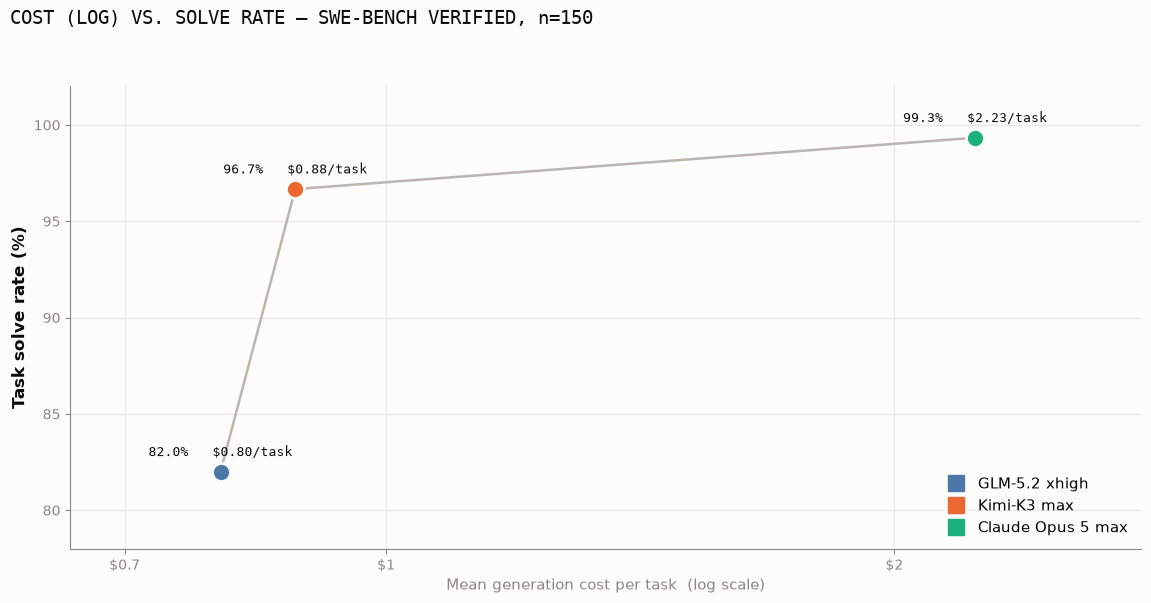

In [5]:
SURFACE = '#fcfcfb'; INK = '#0b0b0b'; MUTED = '#898781'; GRID = '#e8e7e1'; CONNECT = '#b8b6ae'
MONO = 'DejaVu Sans Mono'
pts = comparison.reset_index().sort_values('cost_per_task_usd')

fig, ax = plt.subplots(figsize=(11.6, 6.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.plot(pts.cost_per_task_usd, pts.solve_rate_pct, color=CONNECT, lw=1.8, zorder=2, solid_capstyle='round')
for _, p in pts.iterrows():
    ax.plot(p.cost_per_task_usd, p.solve_rate_pct, 'o', ms=13, color=p.color,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=4)
    ax.annotate(f'{p.solve_rate_pct:.1f}%   ${p.cost_per_task_usd:.2f}/task',
                (p.cost_per_task_usd, p.solve_rate_pct), xytext=(0, 9),
                textcoords='offset points', ha='center', va='bottom',
                fontsize=9.5, color=INK, fontfamily=MONO, zorder=5)

ax.set_xscale('log')
ax.set_xlim(0.65, 2.8); ax.set_ylim(78, 102)
ax.xaxis.set_major_locator(FixedLocator([0.7, 1.0, 2.0]))
ax.xaxis.set_minor_locator(FixedLocator([]))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:.1f}' if v < 1 else f'${v:.0f}'))
ax.set_yticks([80, 85, 90, 95, 100])
ax.set_ylabel('Task solve rate (%)', fontsize=12, fontweight='bold', color=INK)
ax.set_xlabel('Mean generation cost per task  (log scale)', fontsize=10.5, color=MUTED)
ax.grid(True, color=GRID, lw=0.8, zorder=0); ax.set_axisbelow(True)
for side in ('top', 'right'): ax.spines[side].set_visible(False)
for side in ('left', 'bottom'): ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=10)
ax.legend(handles=[Line2D([], [], marker='s', ls='', ms=11, color=row.color, label=row.model)
                   for row in pts.itertuples()], loc='lower right', frameon=False,
          handletextpad=0.5, fontsize=10.5)
fig.suptitle('COST (LOG) VS. SOLVE RATE — SWE-BENCH VERIFIED, n=150',
             x=0.012, y=0.975, ha='left', va='top', fontsize=13.5, fontfamily=MONO, color=INK)
fig.tight_layout(rect=[0, 0.01, 1, 0.93])
out = REPO / 'notebooks/cost_vs_accuracy_n150.png'
fig.savefig(out, dpi=170, facecolor=SURFACE)
print(f'saved -> {out}')
plt.show()